<a href="https://colab.research.google.com/github/hollymunck-glitch/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data.csv` file you exported from Assignment 6.

📌 In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [9]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 0) Load
# -------------------------------
df = pd.read_csv("/content/sample_data/listings.csv.gz", low_memory=False)
print("Raw shape:", df.shape)

# -------------------------------
# 1) Clean column names
# -------------------------------
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(r"\s+", "_", regex=True)
              .str.replace(r"[^0-9a-zA-Z_]", "", regex=True)
)

# -------------------------------
# 2) Trim whitespace in string cols
# -------------------------------
obj_cols = df.select_dtypes(include=["object"]).columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

# -------------------------------
# 3) Convert price/fee-like columns to numeric
#    (removes $, commas; works for cleaning_fee, price, security_deposit, etc.)
# -------------------------------
money_keywords = ["price", "fee", "deposit", "revenue", "payout", "earnings"]
money_cols = [c for c in df.columns if any(k in c for k in money_keywords)]
for c in money_cols:
    df[c] = (
        df[c].astype(str)
             .str.replace(r"[\$,]", "", regex=True)
             .str.replace("nan", "", regex=False)
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# -------------------------------
# 4) Parse bathrooms_text -> bathrooms (numeric)
#    e.g., "1 bath", "1.5 shared baths" -> 1.5
# -------------------------------
if "bathrooms_text" in df.columns and "bathrooms" not in df.columns:
    def parse_bath(x):
        m = re.search(r"(\d+\.?\d*)", str(x))
        return float(m.group(1)) if m else np.nan
    df["bathrooms"] = df["bathrooms_text"].apply(parse_bath)

# -------------------------------
# 5) Datetime columns (common in Airbnb)
# -------------------------------
date_like = [
    "host_since", "first_review", "last_review",
    "calendar_last_scraped", "last_scraped", "scrape_id"
]
for c in [c for c in date_like if c in df.columns]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

# -------------------------------
# 6) Boolean-ish columns: map yes/no, t/f, true/false to 1/0
# -------------------------------
def looks_boolean(series: pd.Series) -> bool:
    vals = set(series.dropna().astype(str).str.lower().unique().tolist()[:20])
    candidates = {"t","f","true","false","yes","no","y","n"}
    return len(vals) > 0 and vals.issubset(candidates)

for c in obj_cols:
    if looks_boolean(df[c]):
        df[c] = df[c].str.lower().map(
            {"t":1,"true":1,"yes":1,"y":1,"f":0,"false":0,"no":0,"n":0}
        ).astype("float")

# -------------------------------
# 7) Force numeric for common numeric text columns
# -------------------------------
numeric_maybes = [
    "bedrooms","beds","accommodates","minimum_nights","maximum_nights",
    "availability_30","availability_60","availability_90","availability_365",
    "number_of_reviews","review_scores_rating","review_scores_cleanliness",
    "review_scores_communication","review_scores_checkin","review_scores_accuracy",
    "review_scores_location","review_scores_value","reviews_per_month",
    "latitude","longitude","bathrooms"
]
for c in [c for c in numeric_maybes if c in df.columns]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# -------------------------------
# 8) Drop duplicate rows (prefer id if present)
# -------------------------------
if "id" in df.columns:
    before = df.shape[0]
    df = df.drop_duplicates(subset=["id"])
    print(f"Deduped by id: removed {before - df.shape[0]} rows.")
else:
    before = df.shape[0]
    df = df.drop_duplicates()
    print(f"Deduped full rows: removed {before - df.shape[0]} rows.")

# -------------------------------
# 9) Missing values: numeric -> median, categorical -> mode/'unknown'
# -------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isna().any():
        mode_val = df[c].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else "unknown"
        df[c] = df[c].fillna(fill_val)

# -------------------------------
# 10) Winsorize numeric columns at 1st/99th percentiles
# -------------------------------
if len(num_cols) > 0:
    lower = df[num_cols].quantile(0.01)
    upper = df[num_cols].quantile(0.99)
    df[num_cols] = df[num_cols].clip(lower=lower, upper=upper, axis=1)

# -------------------------------
# 11) Save cleaned file
# -------------------------------
df.to_csv("cleaned_airbnb_data.csv", index=False)
print("Cleaned shape:", df.shape)
print("Saved -> cleaned_airbnb_data.csv")
df.head()

Raw shape: (459, 79)
Deduped by id: removed 0 rows.
Cleaned shape: (459, 79)
Saved -> cleaned_airbnb_data.csv


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,9293126.7,https://www.airbnb.com/rooms/2992450,1970-01-01 05:37:30.804133828,2025-08-04,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,nan,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,0.0,1,1,0,0,0.07
1,9293126.7,https://www.airbnb.com/rooms/3820211,1970-01-01 05:37:30.804133828,2025-08-04,city scrape,Funky Urban Gem: Prime Central Location - Park...,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.81,4.77,NaN,0.0,4,4,0,0,2.32
2,9293126.7,https://www.airbnb.com/rooms/5651579,1970-01-01 05:37:30.804133828,2025-08-04,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.88,4.76,4.64,NaN,0.0,2,1,1,0,2.97
3,9293126.7,https://www.airbnb.com/rooms/6623339,1970-01-01 05:37:30.804133828,2025-08-04,city scrape,Bright & Cozy City Stay · Top Location + Parking!,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,0.0,4,4,0,0,2.68
4,9293126.7,https://www.airbnb.com/rooms/9005989,1970-01-01 05:37:30.804133828,2025-08-04,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.93,4.87,4.77,NaN,0.0,1,1,0,0,5.67


## 2. Check for Skew in a Numeric Column

Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare


### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



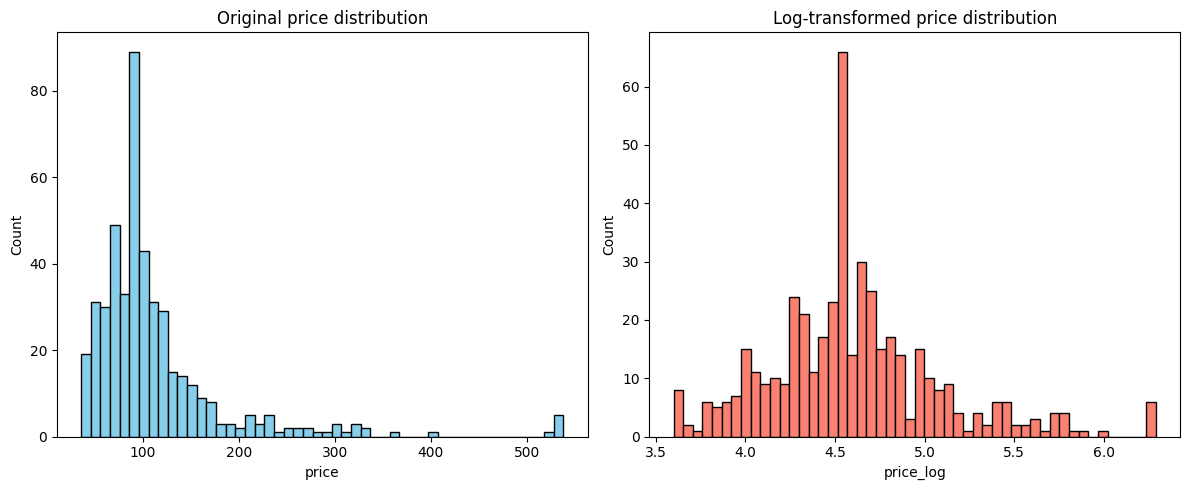

In [10]:
# Add code here 🔧
import matplotlib.pyplot as plt
import numpy as np

# Choose a skewed numeric column (price is usually skewed in Airbnb data)
col = "price"

# Plot original distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df[col], bins=50, color="skyblue", edgecolor="black")
plt.title(f"Original {col} distribution")
plt.xlabel(col)
plt.ylabel("Count")

# Apply log transformation (add 1 to avoid log(0))
df[f"{col}_log"] = np.log1p(df[col])

# Plot transformed distribution
plt.subplot(1,2,2)
plt.hist(df[f"{col}_log"], bins=50, color="salmon", edgecolor="black")
plt.title(f"Log-transformed {col} distribution")
plt.xlabel(f"{col}_log")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


### ✍️ Your Response: 🔧
1. Column examined: I looked at price, since Airbnb prices are often very skewed with a few extreme outliers.

2. Transformation: I used a log transformation to decrease the effect of those very large values and make the distribution closer to normal.

3. Why it helps: The log version makes the data easier to interpret and compare, which is useful for both modeling and explaining results to stakeholders.

## 3. Scale Two Numeric Columns

Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

Follow these steps:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [13]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Pick two numeric columns with different ranges
col1 = "price"              # very large range
col2 = "minimum_nights"     # smaller range

# Min-Max scale col1
scaler_minmax = MinMaxScaler()
df[col1 + "_minmax"] = scaler_minmax.fit_transform(df[[col1]])

# Z-score scale col2
scaler_standard = StandardScaler()
df[col2 + "_zscore"] = scaler_standard.fit_transform(df[[col2]])

# Check
df[[col1, col1 + "_minmax", col2, col2 + "_zscore"]].head()



,price,price_minmax,minimum_nights,minimum_nights_zscore
0,70.0,0.068484,28,2.475196
1,104.0,0.136132,2,-0.405813
2,75.0,0.078432,2,-0.405813
3,101.0,0.130163,2,-0.405813
4,110.0,0.148070,1,-0.516621


### ✍️ Your Response: 🔧
1. What columns did you scale, and which methods did you use?
I scaled price using Min-Max scaling and minimum_nights using Z-score normalization.

2. When might these scaled values be more useful than the originals?
They’re helpful when building models that compare or weigh features on different scales, especially distance-based methods like KNN or clustering.

3. Who at Airbnb might benefit from this transformation and why?
Data scientists or analysts could use scaled values to build fairer models, since one large feature (like price) won’t dominate smaller ones (like nights).

## 4. Group a Numeric Column into Categories

Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

Follow these steps:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [14]:
# Add code here 🔧
# Choose a numeric column to group (e.g., number_of_reviews)
col = "number_of_reviews"

# Create 3 bins: Low, Medium, High
df["review_volume_group"] = pd.cut(
    df[col],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Check the distribution
print(df["review_volume_group"].value_counts())
df[[col, "review_volume_group"]].head()

review_volume_group
Low       422
Medium     26
High       11
Name: count, dtype: int64


,number_of_reviews,review_volume_group
0,9.00,Low
1,310.00,Medium
2,371.00,Medium
3,332.00,Medium
4,557.78,High


### ✍️ Your Response: 🔧
1. What column did you group, and how many categories did you use?
I grouped the number_of_reviews column into 3 categories: Low, Medium, and High.

2. Why might someone prefer this grouped view over raw numbers?
It’s easier to compare listings at a glance without worrying about exact counts. Grouping makes patterns clearer for analysis and communication.

3. Who would this help at Airbnb, and how?
The marketing team could use it to quickly segment listings (e.g., listings with “High” reviews may be promoted differently than “Low” ones).

## 5. Create Two New Business-Relevant Variables

Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

Follow these steps:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [15]:
# Add code here 🔧
# 1. Cost per night (price ÷ minimum_nights)
df["cost_per_night"] = df["price"] / df["minimum_nights"]

# 2. Long-term stay flag (1 if minimum_nights > 30, else 0)
df["long_term_stay"] = (df["minimum_nights"] > 30).astype(int)

# Quick check
df[["price", "minimum_nights", "cost_per_night", "long_term_stay"]].head()


,price,minimum_nights,cost_per_night,long_term_stay
0,70.0,28,2.5,0
1,104.0,2,52.0,0
2,75.0,2,37.5,0
3,101.0,2,50.5,0
4,110.0,1,110.0,0


### ✍️ Your Response: 🔧 🔧
1. What two new columns did you create?
I created cost_per_night (price divided by nights) and long_term_stay (a flag for listings requiring more than 30 nights).

2. Who would use them?
Hosts and managers could use them to set fair pricing, and the platform could use them to target different customer groups.

3. How could they help someone make a better decision?
They make it easier to compare listings by actual nightly rate and identify which properties are focused on long-term rentals, helping with pricing and marketing strategy.



## 6. Encode a Categorical Column

Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [16]:
# Add code here 🔧
# One-hot encode room_type
df_encoded = pd.get_dummies(df, columns=["room_type"], prefix="room")

# Check new columns
print(df_encoded.shape)
df_encoded.filter(like="room_type").head()

(459, 86)


""
0
1
2
3
4


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_2['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

### ✍️ Your Response: 🔧
1. What column did you encode and why?
I encoded room_type because it’s a key feature (entire home, private room, shared room) that impacts price and booking rates.

2. What encoding method did you use?
I used one-hot encoding since room_type is a nominal variable with no natural order.

3. How could this transformation help a pricing model, dashboard, or business report?
It allows models and dashboards to compare listing prices across different room types without misinterpreting them as ordered numbers, giving clearer insights for hosts and Airbnb managers.

## 7. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. What transformation step felt most important or interesting?
I thought the log transformation on price was most interesting because it showed how much cleaner patterns become once extreme outliers are reduced.

2. Which of your changes would be most useful to a host, analyst, or city planner?
The cost_per_night and long_term_stay features would be especially useful, since they highlight affordability and whether listings lean toward short- or long-term stays.

3. If you were going to build a tool or dashboard, what would you do next with this data?
I’d build an interactive dashboard that compares prices, review levels, and availability across neighborhoods so hosts and city planners can make better decisions.

4. How does this relate to your customized learning outcome you created in Canvas?
It connects directly because I wanted to strengthen my data analysis skills, especially preparing raw data into usable insights for business decisions.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_07_LastnameFirstname.ipynb"